Classification for Allergen Detection
===========

In [47]:
# standard library
import warnings

# core libraries
import numpy as np
import pandas as pd

# scikit learn preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# scikit learn models
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

# scikit learn model selction and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# gradient boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# deep learning tabular model
from pytorch_tabnet.tab_model import TabNetClassifier

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

## Preprocessing

In [2]:
# read in data
df = pd.read_csv('foods_health_scores_allergens.csv')
df

,product_name,brands,categories,ingredients,nutriscore_grade,nova_group,ecoscore_grade,allergens,energy_kcal,fat_100g,...,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,food_type
0,Sidi Ali,سيدي علي,"en:beverages-and-beverages-preparations, en:be...",OBD1 999 999 1112606 266963207 mb,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000000,0.000000,False,False,False,False,False,False,Branded/Packaged
1,Perly,Perly,"en:dairies, en:fermented-foods, en:fermented-m...","milk cream, cream, sugar, banana, bacteria",UNKNOWN,3.0,B,"en:banana, en:milk",97.0,3.0,...,8.0,NaN,NaN,False,True,False,False,False,False,Branded/Packaged
2,Sidi Ali,Sidi Ali,"en:beverages-and-beverages-preparations, en:be...","Sodium, Calcium, Magnésium, Potassium, Bicarbo...",A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
3,Eau minérale naturelle,sidi ali,"en:beverages-and-beverages-preparations, en:be...",100% mineral water,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
4,اكوافينا,AQUAFINA,"en:beverages-and-beverages-preparations, en:be...",ouverture et avant le : Voir bouteille. après ...,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000508,0.000203,False,False,False,False,False,False,Branded/Packaged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4992,Crème fraîche gastronomique,Président,"en:dairies, en:fermented-foods, en:fermented-m...","_Crème_ (origine France), _ferments lactiques_",D,3.0,A,en:milk,291.0,30.0,...,2.3,0.070000,0.028000,False,True,False,False,False,False,Branded/Packaged
4993,Noix de cajou grillées sans sel,Maître Prunille,"en:plant-based-foods-and-beverages, en:plant-b...",Noix de cajou,B,1.0,E,en:nuts,621.0,47.0,...,21.0,0.020000,0.008000,False,False,True,False,False,False,Branded/Packaged
4994,Cacao puro en polvo desgrasado,Valor,"en:cocoa-and-its-products, en:cocoa-and-chocol...","Cacao desgrasado en polvo, correctores de acid...",C,1.0,F,NaN,375.0,16.0,...,26.0,0.030000,0.012000,False,False,False,False,False,False,Branded/Packaged
4995,Sablés Myrtilles Germes de riz,Gerblé,"en:snacks, en:sweet-snacks, en:biscuits-and-cakes","Farine de blé 58,2%, huile de colza, sucre de ...",A,4.0,C,"en:gluten, en:milk",54.0,2.0,...,0.9,0.050000,0.020000,True,True,False,False,False,False,Branded/Packaged


In [3]:
# check counts for food_type
df["food_type"].value_counts()

food_type
Branded/Packaged    4997
Name: count, dtype: int64

### Here we can see that the food_type feature is a constant. We will drop it in the next cell.

In [4]:
# drop columns with data leakage or unnecessary info
df = df.drop(['product_name', 'brands', 'categories', 'ingredients', 'allergens', 'food_type', 'sodium_100g'], axis = 1)

### We drop the columns that are either unnecessary, would contribute to data leakage, or are constant. We also dropped the sodium_100g column because it is perfectly correlated with the salt_100g columns

In [5]:
# took boolean or for finding if there are any allergens
cols = [
    'contains_gluten',
    'contains_dairy',
    'contains_nuts',
    'contains_soy',
    'contains_eggs',
    'contains_fish'
]

df['Y'] = df[cols].any(axis=1)

### Use boolean "or" to create a new response column that is "contains any allergens"

In [6]:
# encode the response as 1s and 0s
df['Y'] = df['Y'].astype(int)

In [7]:
# check that Y was encoded correctly
df["Y"]

0       0
1       1
2       0
3       0
4       0
       ..
4992    1
4993    1
4994    0
4995    1
4996    1
Name: Y, Length: 4997, dtype: int64

In [8]:
# drop the old boolean columns
df = df.drop(cols, axis = 1)

### Here we drop the old boolean columns so there is not leakage from them

In [9]:
# look at processed dataframe
df

,nutriscore_grade,nova_group,ecoscore_grade,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,Y
0,A,NaN,NOT-APPLICABLE,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.000000,0
1,UNKNOWN,3.0,B,97.0,3.0,NaN,9.4,NaN,NaN,8.0,NaN,1
2,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0
3,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0
4,A,NaN,NOT-APPLICABLE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000508,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4992,D,3.0,A,291.0,30.0,22.0,2.9,2.9,NaN,2.3,0.070000,1
4993,B,1.0,E,621.0,47.0,8.7,25.0,6.2,4.5,21.0,0.020000,1
4994,C,1.0,F,375.0,16.0,10.0,16.0,0.7,32.0,26.0,0.030000,0
4995,A,4.0,C,54.0,2.0,0.2,7.9,1.9,0.5,0.9,0.050000,1


In [10]:
# remove high fiber value
df = df[(df['fiber_100g'] < 1e6) | (df['fiber_100g'].isna())]
df

,nutriscore_grade,nova_group,ecoscore_grade,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,Y
0,A,NaN,NOT-APPLICABLE,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.000000,0
1,UNKNOWN,3.0,B,97.0,3.0,NaN,9.4,NaN,NaN,8.0,NaN,1
2,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0
3,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0
4,A,NaN,NOT-APPLICABLE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000508,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4992,D,3.0,A,291.0,30.0,22.0,2.9,2.9,NaN,2.3,0.070000,1
4993,B,1.0,E,621.0,47.0,8.7,25.0,6.2,4.5,21.0,0.020000,1
4994,C,1.0,F,375.0,16.0,10.0,16.0,0.7,32.0,26.0,0.030000,0
4995,A,4.0,C,54.0,2.0,0.2,7.9,1.9,0.5,0.9,0.050000,1


### From the EDA notebook, we noticed that there was a fiber value in the trillions. So we dropped that row and verified that that was the only dropped row.

In [11]:
# check remaining columns of the dataframe
df.columns

Index(['nutriscore_grade', 'nova_group', 'ecoscore_grade', 'energy_kcal',
       'fat_100g', 'saturated_fat_100g', 'carbs_100g', 'sugars_100g',
       'fiber_100g', 'proteins_100g', 'salt_100g', 'Y'],
      dtype='str')

In [12]:
# set response as y and features as X
y = df["Y"]
X = df.drop("Y", axis = 1)

In [13]:
# check value counts of Y
y.value_counts(normalize = True)

Y
1    0.621697
0    0.378303
Name: proportion, dtype: float64

### We see that 62% of the response were positive results. So our response is unbalanced.

In [14]:
# make trainval and test sets
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=5831,      
    stratify=y           
)

In [15]:
print(f"X_trainval has shape: {X_trainval.shape}")
print(f"X_test has shape: {X_test.shape}")
print(f"y_trainval has shape: {y_trainval.shape}")
print(f"y_test has shape: {y_test.shape}")

X_trainval has shape: (3996, 11)
X_test has shape: (1000, 11)
y_trainval has shape: (3996,)
y_test has shape: (1000,)


In [16]:
# make train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2,        
    random_state=5831,      
    stratify=y_trainval           
)

In [17]:
print(f"X_train has shape: {X_train.shape}")
print(f"X_val has shape: {X_val.shape}")
print(f"y_train has shape: {y_train.shape}")
print(f"y_val has shape: {y_val.shape}")

X_train has shape: (3196, 11)
X_val has shape: (800, 11)
y_train has shape: (3196,)
y_val has shape: (800,)


In [18]:
# find baseline recall of test set
baseline_recall = (y_test == 1).mean()
print("Baseline recall:", baseline_recall)

Baseline recall: 0.622


### We see that a baseline recall for the test set is 0.622

In [19]:
# set minimum precision threshold
precision_threshold = 0.7

In [20]:
# define adjust threshold function that finds ideal thresholds and outputs metrics of a model
def adjust_threshold(pipe, X_train, y_train, X_val, y_val, X_test, y_test, X_trainval, y_trainval):
    # fit model initially on train only
    threshold_model = clone(pipe)
    threshold_model.fit(X_train, y_train)

    # get probabilities for validation set
    y_val_prob = threshold_model.predict_proba(X_val)[:, 1]

    # search over thresholds for validation set
    thresholds = np.arange(0.05, 0.96, 0.05)
    recalls = {}

    # for each threshold, find if the precision is above minimum and then store the recall
    for t in thresholds:
        y_val_pred = (y_val_prob >= t).astype(int)
        precision = precision_score(y_val, y_val_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_val, y_val_pred, pos_label=1, zero_division=0)

        if precision >= precision_threshold:
            recalls[t] = recall
            
    # error catching
    if len(recalls) == 0:
        raise ValueError(
            f"No threshold met the precision requirement of {precision_threshold}."
        )

    # find best recall
    best_threshold = max(recalls, key=recalls.get)

    # output best threshold and recall
    print(f"Threshold corresponding to max validation recall is {best_threshold}\n", end='\n')
    print(f"Max validation recall is {recalls[best_threshold]}\n", end='\n')

    # make a clone of the initial pipe
    final_model = clone(pipe)

    # fit final model
    final_model.fit(X_trainval, y_trainval)

    # evaluate on test set
    y_test_prob = final_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    # find test recall and precision
    recall = recall_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    precision = precision_score(y_test, y_test_pred, pos_label=1, zero_division=0)

    # print test recall and precision
    print("Test Recall:"+str(recall)+"\n", end='\n')
    print("Test Precision:"+str(precision)+"\n", end='\n')

    # find confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    # make confusion matrix dataframe
    cm_df = pd.DataFrame(
        cm,
        index=["Actual No Allergen", "Actual Has Allergens"],
        columns=["Pred No Allergen", "Pred Has Allergens"]
    )

    # print confusion matrix
    print(cm_df, end='\n')

    return best_threshold, recall, precision, cm_df, final_model

### This is a function that chooses the best threshold for the classification given the minimum precision defined above

In [21]:
# make empty results dictionary
results_dict = dict()

In [22]:
# define numeric and categorical columns
num_cols = ['energy_kcal','fat_100g', 'saturated_fat_100g', 'carbs_100g', 'sugars_100g','fiber_100g', 'proteins_100g', 'salt_100g']     
cat_cols = ['nutriscore_grade', 'nova_group', 'ecoscore_grade']  

# LDA (Linear Discriminant Analysis)

In [23]:
# define numeric pipeline
num_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# define categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# combine two pipelines
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# full pipeline for LDA
pipe = Pipeline([
    ("preprocess", preprocess),
    ("lda", LinearDiscriminantAnalysis())
])

In [24]:
# find the metrics for lda model
threshold_lda, recall_lda, precision_lda, cm_df_lda, final_model_lda = adjust_threshold(
    pipe, X_train, y_train, X_val, y_val, 
    X_test, y_test, X_trainval, y_trainval)

# store results in the results dictionary
results_dict["LDA"] = {"recall":recall_lda, "precision": precision_lda, "threshold": threshold_lda}

Threshold corresponding to max validation recall is 0.45

Max validation recall is 0.9235412474849095

Test Recall:0.9517684887459807

Test Precision:0.729064039408867

                      Pred No Allergen  Pred Has Allergens
Actual No Allergen                 158                 220
Actual Has Allergens                30                 592


## As we can see, for LDA, the max recall is 0.952 with a precision of 0.729 on the test set.

In [25]:
# define permutation importance for lda
result = permutation_importance(
    final_model_lda, X_test, y_test,
    n_repeats=10,
    random_state=5831,
    n_jobs=-1
)

# store feature importances in a dataframe
imp_lda = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

imp_lda

,feature,importance
0,nutriscore_grade,0.0599
1,nova_group,0.0422
2,ecoscore_grade,0.0420
9,proteins_100g,0.0360
5,saturated_fat_100g,0.0187
7,sugars_100g,0.0136
3,energy_kcal,0.0108
6,carbs_100g,0.0063
4,fat_100g,0.0040
8,fiber_100g,0.0013


# QDA (Quadratic Discriminant Analysis)

In [26]:
# define numerical pipeline for qda
num_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# define categorical pipeline for qda
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# combine preprocessing steps for all columns
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# define overall pipeline
pipe = Pipeline([
    ("preprocess", preprocess),
    ("qda", QuadraticDiscriminantAnalysis(reg_param=0.1))
])

In [27]:
# run threshold function to find key metrics for qda
threshold_qda, recall_qda, precision_qda, cm_df_qda, final_model_qda = adjust_threshold(
    pipe, X_train, y_train, X_val, y_val, 
    X_test, y_test, X_trainval, y_trainval)

# store results in the results dictionary
results_dict["QDA"] = {"recall":recall_qda, "precision": precision_qda, "threshold": threshold_qda}

Threshold corresponding to max validation recall is 0.6500000000000001

Max validation recall is 0.9778672032193159

Test Recall:0.9710610932475884

Test Precision:0.7122641509433962

                      Pred No Allergen  Pred Has Allergens
Actual No Allergen                 134                 244
Actual Has Allergens                18                 604


## As we can see, the max recall for QDA is 0.971 with a precision of 0.712 on the test set. The threshold for this model is at 0.65.

In [28]:
# define permutation importance for qda
result = permutation_importance(
    final_model_qda, X_test, y_test,
    n_repeats=10,
    random_state=5831,
    n_jobs=-1
)

# find feature importances for qda
imp_qda = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

# output qda feature importance dataframe
imp_qda

,feature,importance
2,ecoscore_grade,0.0474
3,energy_kcal,0.0272
4,fat_100g,0.0203
0,nutriscore_grade,0.0201
7,sugars_100g,0.0176
9,proteins_100g,0.0106
1,nova_group,0.0079
5,saturated_fat_100g,0.0078
10,salt_100g,0.0043
8,fiber_100g,0.0021


# Regularized LDA

In [29]:
# define numeric pipeline for regularized lda
num_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# define categorical pipeline for regularized lda
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

# combine preprocessing steps for regularized lda
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# define overall pipeline for lda
pipe = Pipeline([
    ("preprocess", preprocess),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
])

In [30]:
# run threshold function for regularized lda
threshold_reglda, recall_reglda, precision_reglda, cm_df_reglda, final_model_reglda = adjust_threshold(
    pipe, X_train, y_train, X_val, y_val, 
    X_test, y_test, X_trainval, y_trainval)

# store results in a dictionary
results_dict["Reg LDA"] = {"recall":recall_reglda, "precision": precision_reglda, "threshold": threshold_reglda}

Threshold corresponding to max validation recall is 0.45

Max validation recall is 0.9356136820925554

Test Recall:0.9469453376205788

Test Precision:0.7037037037037037

                      Pred No Allergen  Pred Has Allergens
Actual No Allergen                 130                 248
Actual Has Allergens                33                 589


## As we can see, the max recall for Regularized LDA is 0.947 with a precision of 0.703 on the test set. The threshold for this model is at 0.45.

In [31]:
# define permutation importance for regularized lda
result = permutation_importance(
    final_model_reglda, X_test, y_test,
    n_repeats=10,
    random_state=5831,
    n_jobs=-1
)

# define importances for regularized lda
imp_reglda = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

# output importances for regularized lda
imp_reglda

,feature,importance
0,nutriscore_grade,0.0651
2,ecoscore_grade,0.0394
1,nova_group,0.0215
3,energy_kcal,0.0094
9,proteins_100g,0.0090
6,carbs_100g,0.0017
4,fat_100g,0.0015
8,fiber_100g,0.0013
7,sugars_100g,0.0012
10,salt_100g,0.0005


# XGBoost

In [32]:
# define pipeline for numeric features for XGBoost model
num_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])

# define pipeline for categorical features for XGBoost model
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# define preprocessing for XGBoost
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# define overall pipeline for XGBoost
pipe = Pipeline([
    ("preprocess", preprocess),
    ("xgb", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=5831,
        eval_metric="logloss"
    ))
])

In [33]:
# output metrics for XGBoost
threshold_xgb, recall_xgb, precision_xgb, cm_df_xgb, final_model_xgb = adjust_threshold(
    pipe, X_train, y_train, X_val, y_val, 
    X_test, y_test, X_trainval, y_trainval)

# store results for XGBoost in a dictionary
results_dict["XGBoost"] = {"recall":recall_xgb, "precision": precision_xgb, "threshold": threshold_xgb}

Threshold corresponding to max validation recall is 0.1

Max validation recall is 0.9899396378269618

Test Recall:0.9871382636655949

Test Precision:0.7318235995232419

                      Pred No Allergen  Pred Has Allergens
Actual No Allergen                 153                 225
Actual Has Allergens                 8                 614


## As we can see, the max recall for XGBoost is 0.987 with a precision of 0.732 on the test set. The threshold for this model is at 0.1. This is the highest recall so far.

In [34]:
# define permutation importance for XGBoost
result = permutation_importance(
    final_model_xgb, X_test, y_test,
    n_repeats=10,
    random_state=5831,
    n_jobs=-1
)

# store feature importances in a dataframe
imp_xgb = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

imp_xgb

,feature,importance
9,proteins_100g,0.1313
4,fat_100g,0.0532
7,sugars_100g,0.0452
3,energy_kcal,0.0447
6,carbs_100g,0.0447
8,fiber_100g,0.0371
10,salt_100g,0.0325
5,saturated_fat_100g,0.0313
2,ecoscore_grade,0.0261
1,nova_group,0.0032


# Light GBM

In [35]:
# define pipeline for numeric columns for LightGBM
num_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])

# define pipeline for categorical columns for LightGBM
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# overall preprocessing steps for LightGBM
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# define overall pipeline for LightGBM
pipe = Pipeline([
    ("preprocess", preprocess),
    ("lgbm", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=5831
    ))
])

In [36]:
# find key metrics for Light GBM
threshold_lgbm, recall_lgbm, precision_lgbm, cm_df_lgbm, final_model_lgbm = adjust_threshold(
    pipe, X_train, y_train, X_val, y_val, 
    X_test, y_test, X_trainval, y_trainval)

# store results for LightGBM in the results dictionary
results_dict["Lightgbm"] = {"recall":recall_lgbm, "precision": precision_lgbm, "threshold": threshold_lgbm}

[LightGBM] [Info] Number of positive: 1987, number of negative: 1209
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2034
[LightGBM] [Info] Number of data points in the train set: 3196, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.621715 -> initscore=0.496832
[LightGBM] [Info] Start training from score 0.496832


/opt/anaconda3/envs/CS5831FinalClassification/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold corresponding to max validation recall is 0.05

Max validation recall is 0.9979879275653923

[LightGBM] [Info] Number of positive: 2484, number of negative: 1512
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2046
[LightGBM] [Info] Number of data points in the train set: 3996, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.621622 -> initscore=0.496437
[LightGBM] [Info] Start training from score 0.496437
Test Recall:0.9935691318327974

Test Precision:0.7136258660508084

                      Pred No Allergen  Pred Has Allergens
Actual No Allergen                 130                 248
Actual Has Allergens                 4                 618


/opt/anaconda3/envs/CS5831FinalClassification/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## As we can see, the max recall for Light GBM is 0.994 with a precision of 0.714 on the test set. The threshold for this model is at 0.05. This is the highest recall so far, though the precision is lower than that of XGBoost

In [37]:
# make empty dataframe for importances
imp_lgbm = pd.DataFrame()

# suppress warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # define permuation importance for LightGBM
    result = permutation_importance(
    final_model_lgbm, X_test, y_test,
    n_repeats=10,
    random_state=5831,
    n_jobs=-1
    )

    # fill out importances for lightGBM
    imp_lgbm = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
    }).sort_values(by="importance", ascending=False)

# output importances for LightGBM
imp_lgbm

,feature,importance
9,proteins_100g,0.1241
4,fat_100g,0.0590
3,energy_kcal,0.0575
7,sugars_100g,0.0542
8,fiber_100g,0.0431
6,carbs_100g,0.0426
10,salt_100g,0.0381
5,saturated_fat_100g,0.0360
2,ecoscore_grade,0.0319
0,nutriscore_grade,0.0094


# Tabnet

### The code for tabnet needed to be implemented in a different way according to what we read. Thus it is more of a manual approach to doing a small grid search. Initially the grid was wider, but we narrowed it over time.

In [38]:
# make empty results list
results = []

# transform and fit on training
X_train_trans = preprocess.fit_transform(X_train).astype(np.float32)
X_val_trans   = preprocess.transform(X_val).astype(np.float32)

# make numpy arrays for responses
y_train_np = y_train.to_numpy()
y_val_np   = y_val.to_numpy()

# define a range of thresholds
thresholds = np.arange(0.05, 0.96, 0.05)

lr = 0.05

# grid search
for n_d in [32, 64]:
    for n_steps in [5, 7]:
        # define model with chosen parameters
        model = TabNetClassifier(
            seed=5831,
            n_d=n_d,
            n_a=n_d,
            n_steps=n_steps,
            gamma=1.5,
            lambda_sparse=1e-4,
            optimizer_params=dict(lr=lr),
            mask_type="entmax",
            verbose=0
        )

        # fit model using train set
        model.fit(
            X_train_trans,
            y_train_np,
            eval_set=[(X_val_trans, y_val_np)],
            eval_name=["valid"],
            eval_metric=["auc"],
            max_epochs=200,
            patience=20,
            batch_size=256,
            virtual_batch_size=64,
            num_workers=0,
            drop_last=False
        )

        # find probabilities
        y_val_prob = model.predict_proba(X_val_trans)[:, 1]

        # define absolute minimum recall, threshold, and precision
        best_recall = -1
        best_t = None
        best_precision = None

        # threshold search
        for t in thresholds:
            y_val_pred_t = (y_val_prob >= t).astype(int)

            # find precision and recall on validation set
            precision = precision_score(y_val, y_val_pred_t, pos_label=1, zero_division=0)
            recall = recall_score(y_val, y_val_pred_t, pos_label=1, zero_division=0)

            # must meet minimum precision threshold. If so, store results
            if precision >= precision_threshold:
                if recall > best_recall:
                    best_recall = recall
                    best_t = t
                    best_precision = precision

        # append results to the results list
        results.append({
            "n_d": n_d,
            "n_steps": n_steps,
            "lr": lr,
            "best_threshold": best_t,
            "valid_pos_recall": best_recall,
            "precision": best_precision
        })


Early stopping occurred at epoch 38 with best_epoch = 18 and best_valid_auc = 0.75842


/opt/anaconda3/envs/CS5831FinalClassification/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 40 with best_epoch = 20 and best_valid_auc = 0.81157


/opt/anaconda3/envs/CS5831FinalClassification/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 44 with best_epoch = 24 and best_valid_auc = 0.84668


/opt/anaconda3/envs/CS5831FinalClassification/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 44 with best_epoch = 24 and best_valid_auc = 0.83248


/opt/anaconda3/envs/CS5831FinalClassification/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [39]:
# make a dataframe out of the results list and output it
results_df = pd.DataFrame(results).sort_values("valid_pos_recall", ascending=False)
results_df

,n_d,n_steps,lr,best_threshold,valid_pos_recall,precision
2,64,5,0.05,0.45,0.967807,0.713650
1,32,7,0.05,0.45,0.965795,0.723982
3,64,7,0.05,0.35,0.965795,0.723982
0,32,5,0.05,0.50,0.901408,0.706625


## As we can see, the best validation recall was 0.968 with a precision of .714.

## Here we take the best model and then train the trainval set with those parameters.

In [40]:
# find the best row from the results
best_row = results_df.iloc[0]

# find best n_d, n_steps, lr, and threshold from results
best_n_d = int(best_row["n_d"])
best_n_steps = int(best_row["n_steps"])
best_lr = float(best_row["lr"])
best_threshold = float(best_row["best_threshold"])

# make transformed trainval and test sets
X_trainval_trans = preprocess.fit_transform(X_trainval).astype(np.float32)

# make transformed trainval and test sets
y_trainval_np = y_trainval.to_numpy()

# define final model with best parameters
final_model_tabnet = TabNetClassifier(
    seed=5831,
    n_d=best_n_d,
    n_a=best_n_d,
    n_steps=best_n_steps,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=best_lr),
    mask_type="entmax",
    verbose=0
)

# fit final model with best prameters
final_model_tabnet.fit(
    X_trainval_trans,
    y_trainval_np,
    max_epochs=200,
    batch_size=256,
    virtual_batch_size=64,
    num_workers=0,
    drop_last=False
)

/opt/anaconda3/envs/CS5831FinalClassification/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


In [41]:
# find X test and y test transformed
X_test_trans = preprocess.transform(X_test).astype(np.float32)
y_test_np = y_test.to_numpy()

# predict probablities using final model and test set
y_test_prob = final_model_tabnet.predict_proba(X_test_trans)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

# find final recall and precision using final model
recall_tabnet = recall_score(y_test, y_test_pred, pos_label=1)
precision_tabnet = precision_score(y_test, y_test_pred, pos_label=1)
cm = confusion_matrix(y_test, y_test_pred)

# make confusion matrix dataframe
cm_tabnet = pd.DataFrame(
        cm,
        index=["Actual No Allergen", "Actual Has Allergens"],
        columns=["Pred No Allergen", "Pred Has Allergens"]
)

# output metrics
print("Test Recall:"+str(recall_tabnet)+"\n\n")
print("Test Precision:"+str(precision_tabnet)+"\n\n")
print(cm_tabnet)

Test Recall:0.9196141479099679


Test Precision:0.7698519515477793


                      Pred No Allergen  Pred Has Allergens
Actual No Allergen                 207                 171
Actual Has Allergens                50                 572


## As we can see, the test recall was 0.920 and the precision was 0.770 for tabnet. It was the lowest test recall so far.

In [42]:
# store metrics for tabnet
results_dict["Tabnet"] = {"recall":recall_tabnet, "precision": precision_tabnet, "threshold": best_threshold}

In [43]:
# make empty dataframe for importances
imp_tabnet = pd.DataFrame()

# find feature names
feature_names = preprocess.get_feature_names_out()


# suppress warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # define permuation importance for tabnet
    result = permutation_importance(
    final_model_tabnet, X_test_trans, y_test_np, 
    n_repeats=10,
    random_state=5831,
    n_jobs=-1,
    scoring="recall"
    )

    imp_tabnet = pd.DataFrame({
        "feature": feature_names,
        "importance": result.importances_mean
    }).sort_values(by="importance", key=lambda x: np.abs(x), ascending=False)

# output importances for tabnet
imp_tabnet

,feature,importance
1,num__fat_100g,0.064791
26,cat__ecoscore_grade_NOT-APPLICABLE,0.037460
6,num__proteins_100g,0.037299
4,num__sugars_100g,0.022186
18,cat__nova_group_4.0,0.019453
27,cat__ecoscore_grade_UNKNOWN,0.016559
19,cat__ecoscore_grade_A,0.011897
15,cat__nova_group_1.0,0.011254
12,cat__nutriscore_grade_E,0.009646
20,cat__ecoscore_grade_A-PLUS,0.009486


# Results

In [44]:
model_results_df = pd.DataFrame.from_dict(results_dict, orient="index").reset_index()
model_results_df.rename(columns={"index": "model"}, inplace=True)

model_results_df = model_results_df.sort_values(by=["recall", "precision"], ascending = False).reset_index(drop = True)
model_results_df.index += 1
model_results_df

,model,recall,precision,threshold
1,Lightgbm,0.993569,0.713626,0.05
2,XGBoost,0.987138,0.731824,0.10
3,QDA,0.971061,0.712264,0.65
4,LDA,0.951768,0.729064,0.45
5,Reg LDA,0.946945,0.703704,0.45
6,Tabnet,0.919614,0.769852,0.45


### As we can see, lightGBM had the highest recall of all the models. However, it had lower precision than that of XGBoost, so we selected XGBoost as the best model. 

### Consequently, here are the confusion matrix for XGBoost and its feature importances.

In [45]:
cm_df_xgb

,Pred No Allergen,Pred Has Allergens
Actual No Allergen,153,225
Actual Has Allergens,8,614


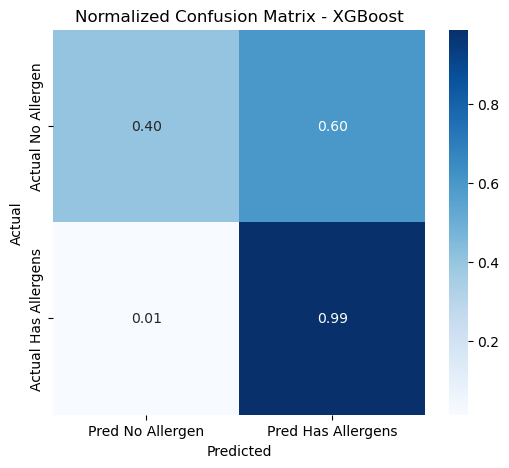

In [48]:
# normalize the confusion matrix
cm_norm = cm_df_xgb / cm_df_xgb.sum(axis=1).values.reshape(-1, 1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix - XGBoost')

plt.show()

### As could be expected with a high recall, almost all of the positive samples were correctly identified. We felt that this was the most important metric, as we envisioned the case where our model would be used to help identify a food as safe or not for someone with allergies.

### Unfortunately, you can see that there are quite a few false negatives (225). This would mean that our model would identify food as unsafe for some when it is in fact safe. In the future, it would be advisable to find a model that has a greater precision while keeping the recall as high as it is.

In [49]:
imp_xgb = imp_xgb.reset_index(drop = True)
imp_xgb.index += 1
imp_xgb

,feature,importance
1,proteins_100g,0.1313
2,fat_100g,0.0532
3,sugars_100g,0.0452
4,energy_kcal,0.0447
5,carbs_100g,0.0447
6,fiber_100g,0.0371
7,salt_100g,0.0325
8,saturated_fat_100g,0.0313
9,ecoscore_grade,0.0261
10,nova_group,0.0032


## From the final feature importances for XGBoost, you can see that proteins, fats, sugars, calories, and carbs were the most impactful for determining if a food has allergens or not. Proteins had the highest importance

# Summary

#### In conclusion, we loaded in our data and did initial preprocessing to drop features that were unsuitable for our classification due to data leakage or their status as ids. We then created a new response variable (has allergens) from the boolean columns already present and then dropped them. We trained 6 models (LDA, QDA, Regularized LDA, LightGBM, XGBoost, and Tabnet) and found that overall XGBoost was the best performing of them. XGBoost had a test recall of 98.7% and a test precision of 73.2%. We propose that our model would be helpful in a cautious prediction of whether a food would be safe for a consumer with any kind of allergy.